# Phase 2: FGSM Attack & Best-of-Breed Defenses on Florence-2 (Variant 2)

## Overview
This notebook evaluates Florence-2-Base's adversarial robustness under FGSM attack with the **best 5 defenses** selected from both classic and recent (2024–2025) research.

### Defense Selection Rationale
| Defense | Source | Why Selected |
|---|---|---|
| JPEG Compression | Dziugaite et al., 2016 | Consistently effective baseline across all studies |
| DiffPure (Diffusion) | Nie et al., ICML 2022 | Most powerful generative purification, SOTA |
| Non-Local Means | Buades et al., 2005 | Outperforms Gaussian blur — preserves texture while denoising |
| Total Variance Minimization | Guo et al., ICLR 2018 | Strong denoiser, different mechanism from filtering |
| SmoothVLM Ensemble | Sun et al., 2024 | VLM-specific, most novel — directly designed for VLMs |

### What's NOT included (and why)
- Gaussian Blur → outclassed by NLM (same category, worse results)
- Median Filter → same category as NLM, less effective on FGSM perturbations
- SVD Spectral → less proven in literature for FGSM specifically
- Bit Depth Reduction → similar mechanism as JPEG, redundant
- Random Resize+Pad → black padding regions hurt clean performance significantly

### Evaluation Protocol
- All conditions use **identical** inference: single `<OD>` prompt, standard NMS, raw model scores.
- The **only variable** is what happens to the image before inference.

## 1. Setup and Imports

In [1]:
import os
import json
import torch
import numpy as np
from PIL import Image, ImageFilter
from io import BytesIO
from tqdm.auto import tqdm
from transformers import AutoProcessor, AutoModelForCausalLM
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchvision import transforms
import GPUtil
import time
import warnings
import gc
import matplotlib.pyplot as plt
import cv2
from skimage.restoration import denoise_tv_chambolle

warnings.filterwarnings("ignore")

# Optional: DiffPure requires diffusers
DIFFPURE_AVAILABLE = False
try:
    from diffusers import DDPMScheduler, UNet2DModel
    DIFFPURE_AVAILABLE = True
    print("diffusers available -- DiffPure defense enabled")
except ImportError:
    print("diffusers not installed -- DiffPure defense disabled")
    print("Install with: pip install diffusers")

print("All core imports successful.")

/data1/cs24mtech14020/miniconda3/envs/vlm_ftune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


diffusers available -- DiffPure defense enabled
All core imports successful.


## 1.5 GPU Diagnostics & Device Selection
Print all available GPUs, their memory usage, and select the most free one.

In [2]:
# ============================================================
# GPU DIAGNOSTICS -- Auto-select most free single GPU
# ============================================================
import subprocess

print("=" * 70)
print("GPU DIAGNOSTICS")
print("=" * 70)

try:
    result = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=10)
    print(result.stdout)
except Exception as e:
    print(f"nvidia-smi failed: {e}")

print("-" * 70)
n_gpus = torch.cuda.device_count()
print(f"Total GPUs found: {n_gpus}")

# Pick GPU with most free memory using torch (works after torch import)
best_gpu = 0
best_free = 0
for i in range(n_gpus):
    free, total = torch.cuda.mem_get_info(i)
    props = torch.cuda.get_device_properties(i)
    used_pct = (total - free) / total * 100
    print(f"  GPU {i}: {props.name}")
    print(f"    Memory: {(total-free)/1024**2:.0f}MB used / {total/1024**2:.0f}MB total ({used_pct:.1f}% used)")
    print(f"    Free: {free/1024**3:.2f} GB")
    if free > best_free:
        best_free = free
        best_gpu = i

selected_gpu = best_gpu
torch.cuda.set_device(selected_gpu)
device = torch.device(f"cuda:{selected_gpu}")
torch_dtype = torch.float16

props = torch.cuda.get_device_properties(selected_gpu)
print(f"\n>> Selected GPU {selected_gpu}: {props.name} ({best_free/1024**3:.2f} GB free)")
print(f"\nDevice: {device}")
print(f"Dtype: {torch_dtype}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print("=" * 70)


GPU DIAGNOSTICS
Sat Apr 11 03:47:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:3B:00.0 Off |                  Off |
| 30%   31C    P8             20W /  300W |      13MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------------------

## 2. Configuration

In [3]:
# ============================================================
# CONFIGURATION
# ============================================================

# Dataset paths
IMAGE_DIR = "./val2017"
ANN_FILE = "./annotations/instances_val2017.json"

# Number of images (None = all 5000)
NUM_IMAGES = 500

# FGSM epsilon values
EPSILONS = [0.003, 0.01, 0.03]

# Defenses to run
RUN_JPEG_DEFENSE = True
RUN_DIFFPURE_DEFENSE = DIFFPURE_AVAILABLE
RUN_NLM_DEFENSE = True
RUN_TVM_DEFENSE = True
RUN_SMOOTHVLM_DEFENSE = True

# Defense parameters
JPEG_QUALITY = 75              # Dziugaite et al., 2016
DIFFPURE_TIMESTEPS = 100       # Nie et al., 2022
NLM_H = 10                     # NLM filter strength
NLM_TEMPLATE = 7               # NLM template window
NLM_SEARCH = 21                # NLM search window
TVM_WEIGHT = 0.1               # Guo et al., 2018
SMOOTHVLM_N = 5                # Number of random views

# NMS threshold (same for ALL conditions)
NMS_IOU_THRESHOLD = 0.5

# Output directory
OUTPUT_DIR = "./results_phase2_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded.")
print(f"  Images: {NUM_IMAGES or 'all'}")
print(f"  Epsilons: {EPSILONS}")
print(f"  Defenses: JPEG={RUN_JPEG_DEFENSE}, DiffPure={RUN_DIFFPURE_DEFENSE}, "
      f"NLM={RUN_NLM_DEFENSE}, TVM={RUN_TVM_DEFENSE}, SmoothVLM={RUN_SMOOTHVLM_DEFENSE}")

Configuration loaded.
  Images: 500
  Epsilons: [0.003, 0.01, 0.03]
  Defenses: JPEG=True, DiffPure=True, NLM=True, TVM=True, SmoothVLM=True


## 3. Load Model and Dataset

In [4]:
# Device already selected in GPU Diagnostics cell above
print(f"Using device: {device}, dtype: {torch_dtype}")

model_name = "microsoft/Florence-2-base"
revision = "refs/pr/26"

print("Loading Florence-2-Base model...")
model = AutoModelForCausalLM.from_pretrained(
    model_name, revision=revision,
    torch_dtype=torch_dtype, trust_remote_code=True
).to(device)
print("Model loaded.")

processor = AutoProcessor.from_pretrained(
    model_name, revision=revision, trust_remote_code=True
)

coco_gt = COCO(ANN_FILE)
categories = coco_gt.loadCats(coco_gt.getCatIds())
category_mapping = {c["name"]: c["id"] for c in categories}
print(f"COCO categories loaded: {len(category_mapping)}")

IMG_MEAN = torch.tensor(processor.image_processor.image_mean, device=device, dtype=torch_dtype).view(1, 3, 1, 1)
IMG_STD = torch.tensor(processor.image_processor.image_std, device=device, dtype=torch_dtype).view(1, 3, 1, 1)

files = sorted(os.listdir(IMAGE_DIR))
if NUM_IMAGES is not None:
    files = files[:NUM_IMAGES]
print(f"Will process {len(files)} images.")


Using device: cuda:0, dtype: torch.float16
Loading Florence-2-Base model...
Model loaded.
loading annotations into memory...
Done (t=0.71s)
creating index...
index created!
COCO categories loaded: 80
Will process 500 images.


## 4. Core Utilities: NMS and Inference

In [5]:
def box_iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0


def non_max_suppression(boxes, labels, scores, iou_thr=0.5):
    if not boxes:
        return [], [], []
    boxes = np.array(boxes)
    idxs = np.argsort(scores)[::-1]
    keep, keep_labels, keep_scores = [], [], []
    for i in idxs:
        suppress = False
        for j in keep:
            if labels[i] == labels[j] and box_iou(boxes[i], boxes[j]) > iou_thr:
                suppress = True
                break
        if not suppress:
            keep.append(i)
            keep_labels.append(labels[i])
            keep_scores.append(scores[i])
    return boxes[keep].tolist(), keep_labels, keep_scores


def run_inference(pil_img):
    """Run Florence-2 OD. Single <OD> prompt, raw scores, standard NMS."""
    with torch.no_grad():
        inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
        input_ids = inputs.input_ids.to(device)
        pixel_values = inputs.pixel_values.to(device=device, dtype=torch_dtype)
        gen_ids = model.generate(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
        )
        txt = processor.batch_decode(gen_ids, skip_special_tokens=False)[0]
        parsed = processor.post_process_generation(
            txt, task="<OD>", image_size=(pil_img.width, pil_img.height)
        ) or {}

    od = parsed.get("<OD>", {})
    bboxes, labels = od.get("bboxes", []), od.get("labels", [])
    scores = [1.0] * len(bboxes)
    kept_boxes, kept_labels, kept_scores = non_max_suppression(
        bboxes, labels, scores, iou_thr=NMS_IOU_THRESHOLD
    )
    results = []
    for box, label, score in zip(kept_boxes, kept_labels, kept_scores):
        cid = category_mapping.get(label)
        if cid is None:
            continue
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        if w <= 0 or h <= 0:
            continue
        results.append({"bbox": [x1, y1, w, h], "category_id": cid, "score": score})
    return results

print("Inference pipeline ready.")

Inference pipeline ready.


## 5. FGSM Attack
Reference: Goodfellow et al., "Explaining and Harnessing Adversarial Examples," ICLR 2015.

In [6]:
def fgsm_attack(pil_img, eps=0.01):
    orig_size = pil_img.size
    inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
    input_ids = inputs.input_ids.to(device)
    pixel_values = inputs.pixel_values.to(device=device, dtype=torch_dtype)

    with torch.no_grad():
        target_ids = model.generate(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=3, do_sample=False,
        )
    # Ensure labels are [1, seq_len] -- beam search may return extra rows
    target_ids = target_ids[:1, :].contiguous()
    if target_ids.size(1) > 512:
        target_ids = target_ids[:, :512].contiguous()

    pixel_values_adv = pixel_values.clone().detach().requires_grad_(True)
    outputs = model(input_ids=input_ids, pixel_values=pixel_values_adv, labels=target_ids)
    outputs.loss.backward()

    grad_sign = pixel_values_adv.grad.sign()
    adv_pixel_values = pixel_values.detach() + eps * grad_sign
    adv_pixel_values = torch.clamp(adv_pixel_values, -2.5, 2.5)

    # Denormalize: pixel_values shape is [1, C, H, W]
    mean = IMG_MEAN.squeeze(0)   # [C, 1, 1]
    std  = IMG_STD.squeeze(0)    # [C, 1, 1]
    adv_denorm = adv_pixel_values.squeeze(0) * std + mean
    adv_denorm = torch.clamp(adv_denorm, 0.0, 1.0)
    adv_np = (adv_denorm.permute(1, 2, 0).cpu().float().numpy() * 255).astype(np.uint8)
    adv_pil = Image.fromarray(adv_np)
    if adv_pil.size != orig_size:
        adv_pil = adv_pil.resize(orig_size, Image.BICUBIC)
    return adv_pil

print("FGSM attack function ready.")


FGSM attack function ready.


## 6. Defense Functions

Best 5 defenses from classic + recent research:
1. **JPEG Compression** — Dziugaite et al., 2016 *(kept from Variant 1)*
2. **DiffPure** — Nie et al., ICML 2022 *(kept from Variant 1)*
3. **Non-Local Means** — Buades et al., CVPR 2005 *(NEW — replaces Gaussian blur)*
4. **Total Variance Minimization** — Guo et al., ICLR 2018 *(NEW)*
5. **SmoothVLM Ensemble** — Sun et al., arXiv 2024 *(NEW — VLM-specific)*

In [7]:
# ============================================================
# Defense 1: JPEG Compression (from Variant 1)
# Reference: Dziugaite et al., 2016
# ============================================================

def defend_jpeg(pil_img, quality=JPEG_QUALITY):
    """JPEG lossy compression removes high-frequency perturbations via DCT."""
    buffer = BytesIO()
    pil_img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")


# ============================================================
# Defense 2: DiffPure (from Variant 1)
# Reference: Nie et al., ICML 2022
# ============================================================

diffpure_model = None

def _load_diffpure_model():
    global diffpure_model
    if diffpure_model is not None:
        return diffpure_model
    print("Loading DiffPure DDPM model (google/ddpm-ema-church-256)...")
    scheduler = DDPMScheduler.from_pretrained("google/ddpm-ema-church-256")
    unet = UNet2DModel.from_pretrained("google/ddpm-ema-church-256").to(device)
    unet.eval()
    diffpure_model = (unet, scheduler)
    print("DiffPure model loaded.")
    return diffpure_model


def defend_diffpure(pil_img, t_steps=DIFFPURE_TIMESTEPS):
    """
    Diffusion purification: forward diffusion adds noise (pushes off manifold),
    reverse diffusion denoises (projects back), removing adversarial signal.
    """
    if not DIFFPURE_AVAILABLE:
        return pil_img
    unet, scheduler = _load_diffpure_model()
    orig_size = pil_img.size

    img_tensor = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])(pil_img).unsqueeze(0).to(device)
    img_tensor = img_tensor * 2.0 - 1.0

    scheduler.set_timesteps(1000)
    noise = torch.randn_like(img_tensor)
    timestep = torch.tensor([t_steps], device=device, dtype=torch.long)
    noisy_img = scheduler.add_noise(img_tensor, noise, timestep)

    scheduler.set_timesteps(t_steps)
    sample = noisy_img
    for t in scheduler.timesteps:
        with torch.no_grad():
            noise_pred = unet(sample, t).sample
        sample = scheduler.step(noise_pred, t, sample).prev_sample

    sample = (sample.squeeze(0).clamp(-1, 1) + 1.0) / 2.0
    sample_np = (sample.permute(1, 2, 0).cpu().float().numpy() * 255).astype(np.uint8)
    return Image.fromarray(sample_np).resize(orig_size, Image.BICUBIC)


# ============================================================
# Defense 3: Non-Local Means Denoising (NEW)
# Reference: Buades et al., CVPR 2005
# Replaces Gaussian blur -- superior texture preservation
# ============================================================

def defend_nlm(pil_img, h=NLM_H, template_size=NLM_TEMPLATE, search_size=NLM_SEARCH):
    """
    Non-Local Means: each pixel denoised by weighted average of all pixels
    with similar neighborhoods. Preserves texture far better than Gaussian
    blur while effectively removing adversarial noise.
    """
    arr = np.array(pil_img)
    denoised = cv2.fastNlMeansDenoisingColored(arr, None, h, h, template_size, search_size)
    return Image.fromarray(denoised)


# ============================================================
# Defense 4: Total Variance Minimization (NEW)
# Reference: Guo et al., ICLR 2018
# ============================================================

def defend_tvm(pil_img, weight=TVM_WEIGHT):
    """
    Total Variance Minimization: finds a smooth image close to input that
    minimizes total variation. Adversarial perturbations increase TV,
    so minimizing it removes them while preserving structure.
    """
    arr = np.array(pil_img).astype(np.float64) / 255.0
    denoised = denoise_tv_chambolle(arr, weight=weight, channel_axis=-1)
    return Image.fromarray((np.clip(denoised, 0, 1) * 255).astype(np.uint8))


# ============================================================
# Defense 5: SmoothVLM-style Ensemble (NEW)
# Reference: Sun et al., arXiv:2405.10529, 2024
# Adapted for object detection on Florence-2
# ============================================================

def _generate_random_view(pil_img):
    """Generate a randomly cropped + resized view."""
    w, h = pil_img.size
    crop_ratio = np.random.uniform(0.80, 0.95)
    cw, ch = int(w * crop_ratio), int(h * crop_ratio)
    x0 = np.random.randint(0, w - cw + 1)
    y0 = np.random.randint(0, h - ch + 1)
    cropped = pil_img.crop((x0, y0, x0 + cw, y0 + ch))
    return cropped.resize((w, h), Image.BICUBIC)


def defend_smoothvlm(pil_img, n_views=SMOOTHVLM_N):
    """
    SmoothVLM adapted for OD: run inference on N random crops,
    merge all detections via NMS. Adversarial signal is diluted
    across random views. Returns COCO-format detections directly.
    """
    all_boxes, all_labels, all_scores = [], [], []
    for _ in range(n_views):
        view = _generate_random_view(pil_img)
        with torch.no_grad():
            inputs = processor(text="<OD>", images=view, return_tensors="pt")
            input_ids = inputs.input_ids.to(device)
            pixel_values = inputs.pixel_values.to(device=device, dtype=torch_dtype)
            gen_ids = model.generate(
                input_ids=input_ids, pixel_values=pixel_values,
                max_new_tokens=512, num_beams=5, do_sample=False,
            )
            txt = processor.batch_decode(gen_ids, skip_special_tokens=False)[0]
            parsed = processor.post_process_generation(
                txt, task="<OD>", image_size=(pil_img.width, pil_img.height)
            ) or {}
        od = parsed.get("<OD>", {})
        all_boxes.extend(od.get("bboxes", []))
        all_labels.extend(od.get("labels", []))
        all_scores.extend([1.0] * len(od.get("bboxes", [])))

    kept_boxes, kept_labels, kept_scores = non_max_suppression(
        all_boxes, all_labels, all_scores, iou_thr=NMS_IOU_THRESHOLD
    )
    results = []
    for box, label, score in zip(kept_boxes, kept_labels, kept_scores):
        cid = category_mapping.get(label)
        if cid is None:
            continue
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        if w <= 0 or h <= 0:
            continue
        results.append({"bbox": [x1, y1, w, h], "category_id": cid, "score": score})
    return results


# Defense registry -- standard defenses (PIL -> PIL)
DEFENSES = {}
if RUN_JPEG_DEFENSE:
    DEFENSES["jpeg"] = defend_jpeg
if RUN_DIFFPURE_DEFENSE:
    DEFENSES["diffpure"] = defend_diffpure
if RUN_NLM_DEFENSE:
    DEFENSES["nlm"] = defend_nlm
if RUN_TVM_DEFENSE:
    DEFENSES["tvm"] = defend_tvm

# SmoothVLM is special (returns detections directly)
SMOOTHVLM_ENABLED = RUN_SMOOTHVLM_DEFENSE

print(f"Standard defenses: {list(DEFENSES.keys())}")
print(f"SmoothVLM ensemble: {SMOOTHVLM_ENABLED}")

Standard defenses: ['jpeg', 'diffpure', 'nlm', 'tvm']
SmoothVLM ensemble: True


## 6.5 Sanity Check
Quick test to confirm model, dataset, and all defenses are working.

In [8]:
# ============================================================
# SANITY CHECK -- Verify everything works before long run
# ============================================================
print("Running sanity checks...")
errors = []

# Check 1: Dataset paths
if not os.path.isdir(IMAGE_DIR):
    errors.append(f"IMAGE_DIR not found: {IMAGE_DIR}")
else:
    n_imgs = len(os.listdir(IMAGE_DIR))
    print(f"  [OK] Image directory: {n_imgs} files")

if not os.path.isfile(ANN_FILE):
    errors.append(f"ANN_FILE not found: {ANN_FILE}")
else:
    print(f"  [OK] Annotation file exists")

# Check 2: Model inference
try:
    test_img = Image.open(os.path.join(IMAGE_DIR, files[0])).convert("RGB")
    test_dets = run_inference(test_img)
    print(f"  [OK] Model inference: {len(test_dets)} detections on first image")
except Exception as e:
    errors.append(f"Model inference failed: {e}")

# Check 3: FGSM attack
try:
    test_adv = fgsm_attack(test_img, eps=0.01)
    print(f"  [OK] FGSM attack: output size {test_adv.size}")
except Exception as e:
    errors.append(f"FGSM attack failed: {e}")

# Check 4: Each defense
for dname, dfunc in DEFENSES.items():
    try:
        _ = dfunc(test_img)
        print(f"  [OK] {dname} defense")
    except Exception as e:
        errors.append(f"{dname} defense failed: {e}")

if SMOOTHVLM_ENABLED:
    try:
        np.random.seed(42)
        _ = defend_smoothvlm(test_img, n_views=2)
        print("  [OK] SmoothVLM defense (2-view test)")
    except Exception as e:
        errors.append(f"SmoothVLM failed: {e}")

# Check 5: GPU memory
if torch.cuda.is_available():
    mem_alloc = torch.cuda.memory_allocated(device) / 1024**3
    mem_total = torch.cuda.get_device_properties(device).total_memory / 1024**3
    print(f"  [OK] GPU memory: {mem_alloc:.2f}GB / {mem_total:.2f}GB")

# Summary
print()
if errors:
    print(f"FAILED -- {len(errors)} error(s):")
    for e in errors:
        print(f"  x {e}")
else:
    n_conds = 1 + len(DEFENSES) + (1 if SMOOTHVLM_ENABLED else 0)
    n_conds += len(EPSILONS) * (1 + len(DEFENSES) + (1 if SMOOTHVLM_ENABLED else 0))
    print(f"  Images: {len(files)}, Epsilons: {len(EPSILONS)}, Conditions: {n_conds}")
    print(f"  Estimated inference calls: ~{len(files) * n_conds}")

Running sanity checks...
  [OK] Image directory: 5000 files
  [OK] Annotation file exists
  [OK] Model inference: 11 detections on first image
  [OK] FGSM attack: output size (640, 426)
  [OK] jpeg defense
Loading DiffPure DDPM model (google/ddpm-ema-church-256)...


An error occurred while trying to fetch google/ddpm-ema-church-256: google/ddpm-ema-church-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DiffPure model loaded.
  [OK] diffpure defense
  [OK] nlm defense
  [OK] tvm defense
  [OK] SmoothVLM defense (2-view test)
  [OK] GPU memory: 1.52GB / 47.53GB

  Images: 500, Epsilons: 3, Conditions: 24
  Estimated inference calls: ~12000


## 7. COCO Evaluation Helper

In [9]:
def evaluate_coco(results_list, tag="eval"):
    if not results_list:
        print(f"  [{tag}] No detections -- returning zero mAP.")
        return np.zeros(12)
    out_path = os.path.join(OUTPUT_DIR, f"{tag}.json")
    with open(out_path, "w") as f:
        json.dump(results_list, f)
    coco_dt = coco_gt.loadRes(out_path)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    return coco_eval.stats

print("COCO evaluation helper ready.")

COCO evaluation helper ready.


## 8. Main Evaluation Pipeline

In [10]:
def run_full_evaluation():
    start_time = time.time()
    all_results = {}

    conditions = ["clean"]
    for dname in DEFENSES:
        conditions.append(f"clean+{dname}")
    if SMOOTHVLM_ENABLED:
        conditions.append("clean+smoothvlm")
    for eps in EPSILONS:
        eps_tag = f"fgsm_eps{eps}"
        conditions.append(eps_tag)
        for dname in DEFENSES:
            conditions.append(f"{eps_tag}+{dname}")
        if SMOOTHVLM_ENABLED:
            conditions.append(f"{eps_tag}+smoothvlm")

    for cond in conditions:
        all_results[cond] = []

    print(f"Conditions to evaluate: {len(conditions)}")
    for c in conditions:
        print(f"  - {c}")
    print()

    for fname in tqdm(files, desc="Processing images"):
        img_id = int(os.path.splitext(fname)[0])
        img_path = os.path.join(IMAGE_DIR, fname)
        pil_img = Image.open(img_path).convert("RGB")

        # Clean baseline
        clean_dets = run_inference(pil_img)
        for d in clean_dets:
            d["image_id"] = img_id
        all_results["clean"].extend(clean_dets)

        # Clean + standard defenses
        for dname, dfunc in DEFENSES.items():
            defended_clean = dfunc(pil_img)
            dets = run_inference(defended_clean)
            for d in dets:
                d["image_id"] = img_id
            all_results[f"clean+{dname}"].extend(dets)

        # Clean + SmoothVLM
        if SMOOTHVLM_ENABLED:
            np.random.seed(img_id)
            svlm_dets = defend_smoothvlm(pil_img)
            for d in svlm_dets:
                d["image_id"] = img_id
            all_results["clean+smoothvlm"].extend(svlm_dets)

        # For each epsilon
        for eps in EPSILONS:
            eps_tag = f"fgsm_eps{eps}"
            adv_img = fgsm_attack(pil_img, eps=eps)

            # Attacked, no defense
            adv_dets = run_inference(adv_img)
            for d in adv_dets:
                d["image_id"] = img_id
            all_results[eps_tag].extend(adv_dets)

            # Attacked + standard defenses
            for dname, dfunc in DEFENSES.items():
                defended_adv = dfunc(adv_img)
                def_dets = run_inference(defended_adv)
                for d in def_dets:
                    d["image_id"] = img_id
                all_results[f"{eps_tag}+{dname}"].extend(def_dets)

            # Attacked + SmoothVLM
            if SMOOTHVLM_ENABLED:
                np.random.seed((img_id + hash(eps_tag)) & 0xFFFFFFFF)
                svlm_dets = defend_smoothvlm(adv_img)
                for d in svlm_dets:
                    d["image_id"] = img_id
                all_results[f"{eps_tag}+smoothvlm"].extend(svlm_dets)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    elapsed = time.time() - start_time
    print(f"\nAll inference done in {elapsed/60:.1f} minutes.")
    return all_results

all_results = run_full_evaluation()

Conditions to evaluate: 24
  - clean
  - clean+jpeg
  - clean+diffpure
  - clean+nlm
  - clean+tvm
  - clean+smoothvlm
  - fgsm_eps0.003
  - fgsm_eps0.003+jpeg
  - fgsm_eps0.003+diffpure
  - fgsm_eps0.003+nlm
  - fgsm_eps0.003+tvm
  - fgsm_eps0.003+smoothvlm
  - fgsm_eps0.01
  - fgsm_eps0.01+jpeg
  - fgsm_eps0.01+diffpure
  - fgsm_eps0.01+nlm
  - fgsm_eps0.01+tvm
  - fgsm_eps0.01+smoothvlm
  - fgsm_eps0.03
  - fgsm_eps0.03+jpeg
  - fgsm_eps0.03+diffpure
  - fgsm_eps0.03+nlm
  - fgsm_eps0.03+tvm
  - fgsm_eps0.03+smoothvlm



Processing images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [5:47:45<00:00, 41.73s/it]


All inference done in 347.8 minutes.


## 9. COCO Evaluation for All Conditions

In [11]:
eval_stats = {}
for tag, results_list in all_results.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {tag} ({len(results_list)} detections)")
    print(f"{'='*60}")
    stats = evaluate_coco(results_list, tag=tag)
    eval_stats[tag] = stats
print("\nAll evaluations complete.")


Evaluating: clean (2427 detections)
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=6.55s).
Accumulating evaluation results...
DONE (t=1.36s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.030
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.040
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.035
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.044
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.021
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.034
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.035
 Average Recall     (AR) @[ IoU

## 10. Results Summary Table

In [12]:
clean_ap = eval_stats["clean"][0]
clean_ap50 = eval_stats["clean"][1]

all_defense_names = list(DEFENSES.keys())
if SMOOTHVLM_ENABLED:
    all_defense_names.append("smoothvlm")

print("=" * 90)
print(f"{'FGSM ATTACK & DEFENSE RESULTS (VARIANT 2 - BEST 5)':^90}")
print("=" * 90)
print(f"\nClean Baseline:  mAP = {clean_ap:.4f},  AP50 = {clean_ap50:.4f}")
print()

print("-" * 60)
print("TABLE 1: Defense Cost (on CLEAN images, no attack)")
print("-" * 60)
print(f"  {'Condition':<25} {'mAP':>8} {'AP50':>8} {'mAP Drop':>10}")
print(f"  {'clean (baseline)':<25} {clean_ap:>8.4f} {clean_ap50:>8.4f} {'---':>10}")
for dname in all_defense_names:
    tag = f"clean+{dname}"
    if tag in eval_stats:
        ap, ap50 = eval_stats[tag][0], eval_stats[tag][1]
        drop = clean_ap - ap
        print(f"  {'clean + ' + dname:<25} {ap:>8.4f} {ap50:>8.4f} {drop:>+10.4f}")
print()

print("-" * 90)
print("TABLE 2: Attack Impact & Defense Recovery")
print("-" * 90)
for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    atk_drop = clean_ap - atk_ap
    print(f"\n  FGSM eps={eps}:")
    print(f"    {'Condition':<30} {'mAP':>8} {'AP50':>8} {'Recovery':>10} {'Recovery%':>12}")
    print(f"    {'attacked (no defense)':<30} {atk_ap:>8.4f} {eval_stats[eps_tag][1]:>8.4f} {'---':>10} {'---':>12}")
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        if def_tag in eval_stats:
            def_ap, def_ap50 = eval_stats[def_tag][0], eval_stats[def_tag][1]
            recovery = def_ap - atk_ap
            recovery_pct = (recovery / atk_drop * 100) if atk_drop > 0 else 0
            print(f"    {'attacked + ' + dname:<30} {def_ap:>8.4f} {def_ap50:>8.4f} {recovery:>+10.4f} {recovery_pct:>11.1f}%")

print("\n" + "=" * 90)

# Save summary JSON
summary = {"clean_mAP": float(clean_ap), "clean_AP50": float(clean_ap50),
           "defense_cost": {}, "attack_results": {}}
for dname in all_defense_names:
    tag = f"clean+{dname}"
    if tag in eval_stats:
        summary["defense_cost"][dname] = {
            "mAP": float(eval_stats[tag][0]),
            "mAP_drop": float(clean_ap - eval_stats[tag][0]),
        }
for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    atk_drop = clean_ap - atk_ap
    entry = {"attacked_mAP": float(atk_ap), "defenses": {}}
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        if def_tag in eval_stats:
            def_ap = eval_stats[def_tag][0]
            recovery = def_ap - atk_ap
            recovery_pct = (recovery / atk_drop * 100) if atk_drop > 0 else 0
            entry["defenses"][dname] = {
                "mAP": float(def_ap), "recovery": float(recovery),
                "recovery_pct": float(recovery_pct),
            }
    summary["attack_results"][str(eps)] = entry

with open(os.path.join(OUTPUT_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"Summary saved to {OUTPUT_DIR}/summary.json")

                    FGSM ATTACK & DEFENSE RESULTS (VARIANT 2 - BEST 5)                    

Clean Baseline:  mAP = 0.0298,  AP50 = 0.0398

------------------------------------------------------------
TABLE 1: Defense Cost (on CLEAN images, no attack)
------------------------------------------------------------
  Condition                      mAP     AP50   mAP Drop
  clean (baseline)            0.0298   0.0398        ---
  clean + jpeg                0.0292   0.0390    +0.0006
  clean + diffpure            0.0001   0.0001    +0.0296
  clean + nlm                 0.0253   0.0341    +0.0045
  clean + tvm                 0.0258   0.0337    +0.0040
  clean + smoothvlm           0.0070   0.0162    +0.0228

------------------------------------------------------------------------------------------
TABLE 2: Attack Impact & Defense Recovery
------------------------------------------------------------------------------------------

  FGSM eps=0.003:
    Condition                           mAP  

## 11. Visualization

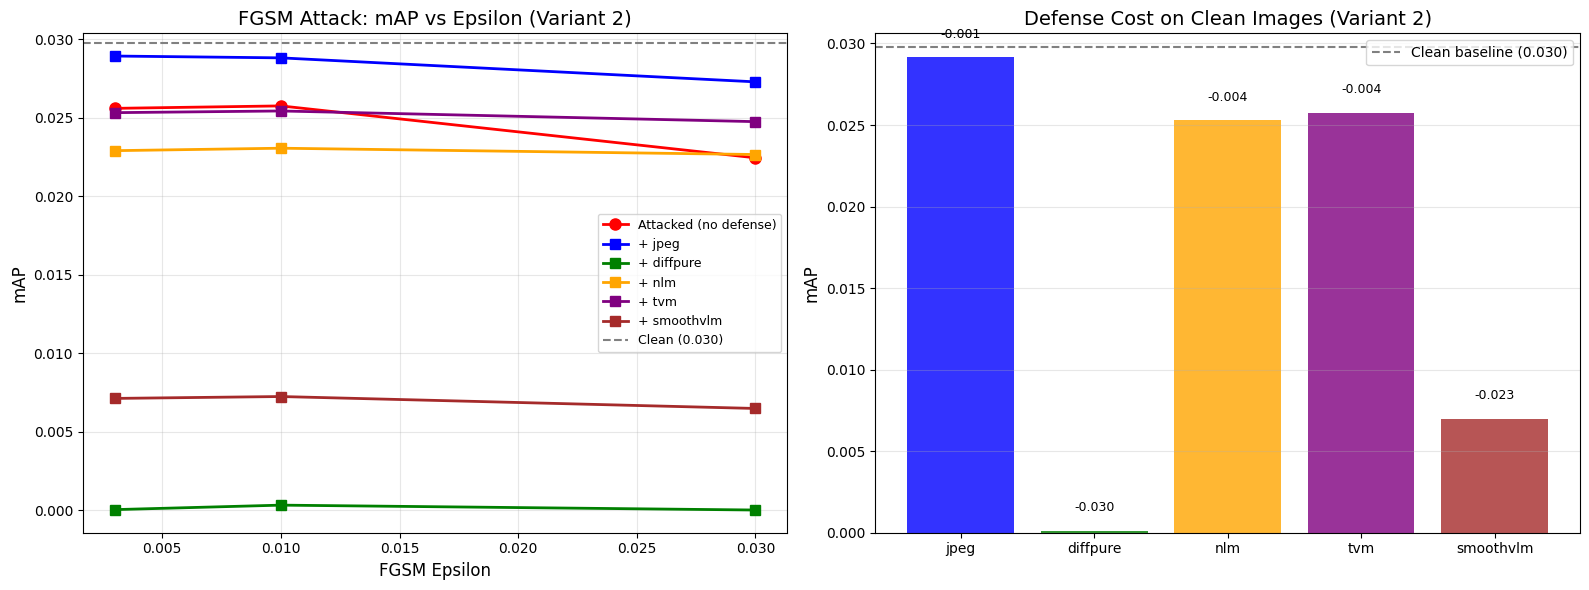

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
atk_maps = [eval_stats[f"fgsm_eps{e}"][0] for e in EPSILONS]
ax.plot(EPSILONS, atk_maps, 'r-o', linewidth=2, markersize=8, label="Attacked (no defense)")

colors = ['blue', 'green', 'orange', 'purple', 'brown']
for i, dname in enumerate(all_defense_names):
    def_maps = [eval_stats.get(f"fgsm_eps{e}+{dname}", np.zeros(12))[0] for e in EPSILONS]
    ax.plot(EPSILONS, def_maps, '-s', color=colors[i % len(colors)],
            linewidth=2, markersize=7, label=f"+ {dname}")

ax.axhline(y=clean_ap, color='gray', linestyle='--', linewidth=1.5, label=f"Clean ({clean_ap:.3f})")
ax.set_xlabel("FGSM Epsilon", fontsize=12)
ax.set_ylabel("mAP", fontsize=12)
ax.set_title("FGSM Attack: mAP vs Epsilon (Variant 2)", fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
clean_maps = [eval_stats.get(f"clean+{d}", np.zeros(12))[0] for d in all_defense_names]
clean_costs = [clean_ap - m for m in clean_maps]
bars = ax.bar(all_defense_names, clean_maps, color=colors[:len(all_defense_names)], alpha=0.8)
ax.axhline(y=clean_ap, color='gray', linestyle='--', linewidth=1.5, label=f"Clean baseline ({clean_ap:.3f})")
for bar, cost in zip(bars, clean_costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"-{cost:.3f}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel("mAP", fontsize=12)
ax.set_title("Defense Cost on Clean Images (Variant 2)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "results_plot_v2.png"), dpi=150, bbox_inches='tight')
plt.show()

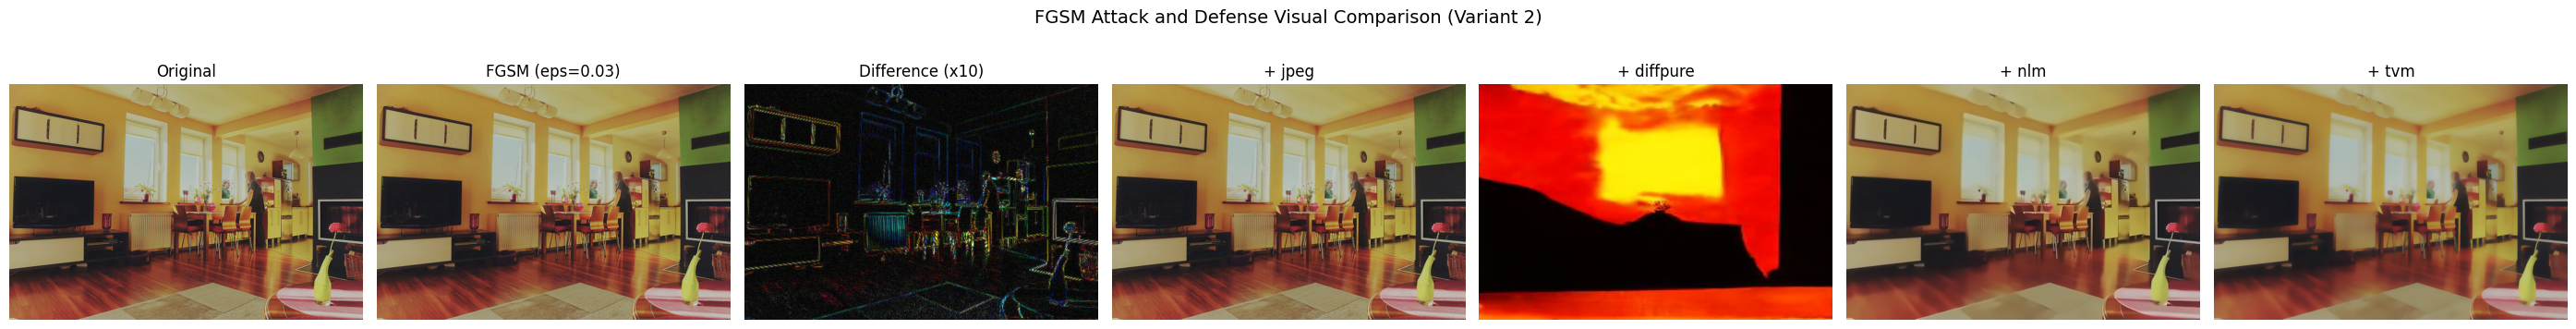

In [14]:
# Visual comparison of defenses on a sample image
sample_fname = files[0]
sample_img = Image.open(os.path.join(IMAGE_DIR, sample_fname)).convert("RGB")
sample_adv = fgsm_attack(sample_img, eps=0.03)

std_names = list(DEFENSES.keys())
ncols = 3 + len(std_names)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

axes[0].imshow(sample_img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(sample_adv); axes[1].set_title("FGSM (eps=0.03)"); axes[1].axis("off")

diff = np.abs(np.array(sample_img).astype(float) - np.array(sample_adv).astype(float))
diff = np.clip(diff * 10, 0, 255).astype(np.uint8)
axes[2].imshow(diff); axes[2].set_title("Difference (x10)"); axes[2].axis("off")

for i, dname in enumerate(std_names):
    defended = DEFENSES[dname](sample_adv)
    axes[3 + i].imshow(defended); axes[3 + i].set_title(f"+ {dname}"); axes[3 + i].axis("off")

plt.suptitle("FGSM Attack and Defense Visual Comparison (Variant 2)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "visual_comparison_v2.png"), dpi=150, bbox_inches='tight')
plt.show()

## 12. Net Gain Analysis

In [15]:
print("=" * 80)
print(f"{'NET GAIN ANALYSIS (VARIANT 2)':^80}")
print("=" * 80)
print("\nNet Gain = defended_mAP - max(clean+defense_mAP, attacked_mAP)")
print("Positive = defense is helpful. Negative = defense makes things worse.\n")

for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    print(f"  FGSM eps={eps} (attacked mAP = {atk_ap:.4f}):")
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        clean_def_tag = f"clean+{dname}"
        if def_tag in eval_stats and clean_def_tag in eval_stats:
            def_ap = eval_stats[def_tag][0]
            clean_def_ap = eval_stats[clean_def_tag][0]
            floor = max(atk_ap, clean_def_ap)
            net_gain = def_ap - floor
            verdict = "HELPFUL" if net_gain > 0 else "NOT HELPFUL"
            print(f"    {dname:<15} defended_mAP={def_ap:.4f}  "
                  f"floor={floor:.4f}  net_gain={net_gain:+.4f}  [{verdict}]")
    print()

                         NET GAIN ANALYSIS (VARIANT 2)                          

Net Gain = defended_mAP - max(clean+defense_mAP, attacked_mAP)
Positive = defense is helpful. Negative = defense makes things worse.

  FGSM eps=0.003 (attacked mAP = 0.0256):
    jpeg            defended_mAP=0.0289  floor=0.0292  net_gain=-0.0002  [NOT HELPFUL]
    diffpure        defended_mAP=0.0001  floor=0.0256  net_gain=-0.0256  [NOT HELPFUL]
    nlm             defended_mAP=0.0229  floor=0.0256  net_gain=-0.0027  [NOT HELPFUL]
    tvm             defended_mAP=0.0253  floor=0.0258  net_gain=-0.0004  [NOT HELPFUL]
    smoothvlm       defended_mAP=0.0071  floor=0.0256  net_gain=-0.0185  [NOT HELPFUL]

  FGSM eps=0.01 (attacked mAP = 0.0258):
    jpeg            defended_mAP=0.0288  floor=0.0292  net_gain=-0.0003  [NOT HELPFUL]
    diffpure        defended_mAP=0.0003  floor=0.0258  net_gain=-0.0254  [NOT HELPFUL]
    nlm             defended_mAP=0.0231  floor=0.0258  net_gain=-0.0027  [NOT HELPFUL]
    

## References

1. Goodfellow, I. et al. "Explaining and Harnessing Adversarial Examples." ICLR, 2015. *(FGSM)*
2. Dziugaite, G. et al. "A Study of the Effect of JPG Compression on Adversarial Images." 2016. *(JPEG defense)*
3. Nie, W. et al. "Diffusion Models for Adversarial Purification." ICML, 2022. *(DiffPure)*
4. Buades, A. et al. "A Non-Local Algorithm for Image Denoising." CVPR, 2005. *(NLM)*
5. Guo, C. et al. "Countering Adversarial Images using Input Transformations." ICLR, 2018. *(TVM)*
6. Sun, J. et al. "Safeguarding VLMs Against Patched Visual Prompt Injectors." arXiv:2405.10529, 2024. *(SmoothVLM)*
7. Xiao, B. et al. "Florence-2." CVPR, 2024. *(Model)*